# LVIS LiDAR Analysis — *Leucadendron argenteum*
## BioSCape 2023 · Table Mountain National Park

**Sensor:** NASA Land, Vegetation and Ice Sensor (LVIS) — Level-2 full-waveform  
**Canopy height metric:** RH98  
**LiDAR acquisition:** October – November 2023  
**Field measurements:** September 2025 · Five tallest *L. argenteum* per plot  
**Study plots:** Seven 10 × 10 m plots — Devil's Peak (Sites 1–5) and Tokai (Sites 6–7)

---

### What this notebook does

| Section | What it produces |
|---|---|
| 1 – Setup | Libraries, figure style, colour palette |
| 2 – File paths | Three paths to check before running |
| 3 – Site polygons | Load the 7 plot boundaries |
| 4 – LVIS data | Stream 100 files without crashing RAM |
| 5 – Waveform profiles | **Figure 1** — vertical structure per site |
| 6 – Field data | Load September 2025 tree heights |
| 7 – Regression | **Figure 2** — two-panel LiDAR vs field comparison |
| 8 – Summary | Numbers ready to paste into your manuscript |

**Run cells from top to bottom. Do not skip any.**


---
## Section 1 — Setup
Run this first. It loads every library and sets the figure style for all plots.

In [1]:
import os, glob, warnings, gc, re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import linregress, t as t_dist
from math import sqrt

warnings.filterwarnings('ignore')

In [2]:
# Publication-quality figure style — applies to every figure automatically
plt.rcParams.update({
    'figure.facecolor'      : 'white',
    'savefig.facecolor'     : 'white',
    'savefig.dpi'           : 300,
    'savefig.bbox'          : 'tight',
    'axes.facecolor'        : 'white',
    'axes.edgecolor'        : '#2a2a2a',
    'axes.linewidth'        : 0.85,
    'axes.spines.top'       : False,
    'axes.spines.right'     : False,
    'axes.titlesize'        : 11,
    'axes.labelsize'        : 10.5,
    'axes.labelcolor'       : '#2a2a2a',
    'axes.grid'             : True,
    'grid.color'            : '#ebebeb',
    'grid.linewidth'        : 0.5,
    'axes.axisbelow'        : True,
    'xtick.labelsize'       : 9.5,
    'ytick.labelsize'       : 9.5,
    'xtick.color'           : '#2a2a2a',
    'ytick.color'           : '#2a2a2a',
    'xtick.major.size'      : 3.5,
    'ytick.major.size'      : 3.5,
    'xtick.direction'       : 'out',
    'ytick.direction'       : 'out',
    'font.family'           : 'sans-serif',
    'font.sans-serif'       : ['Helvetica Neue', 'Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size'             : 10.5,
    'text.color'            : '#2a2a2a',
    'legend.fontsize'       : 9.5,
    'legend.framealpha'     : 0.95,
    'legend.edgecolor'      : '#cccccc',
    'legend.fancybox'       : False,
    'legend.borderpad'      : 0.6,
    'lines.linewidth'       : 1.5,
    'figure.dpi'            : 130,
})

In [3]:
# One distinct colour per site — readable in colour and greyscale print
SITE_COLORS = {
    'Site 1' : '#1A6B9E',   # deep blue
    'Site 2' : '#2E7D52',   # forest green
    'Site 3' : '#A63D2F',   # burnt sienna
    'Site 4' : '#6B4C99',   # deep violet
    'Site 5' : '#C47D17',   # warm amber
    'Site 6' : '#297B8E',   # teal
    'Site 7' : '#4A4A4A',   # charcoal
}
SITE_ORDER = ['Site 1', 'Site 2', 'Site 3', 'Site 4', 'Site 5', 'Site 6', 'Site 7']

---
## Section 2 — File Paths

⚙ **Check these three paths before running anything else.**

In [4]:
LVIS_FOLDER  = "Data/LVIS"                          # Folder with all LVIS .TXT files
PLOT_FOLDER  = "Data/LiDAR/Sites"                   # Folder with study sites
XLSX_PATH    = "Data/LiDAR/Site RH.xlsx"            # Field measurement spreadsheet
OUTPUT_FOLDER = "Data/LiDAR/Outputs/Figures"        # Where to save the final figures

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

lvis_files_found = glob.glob(os.path.join(LVIS_FOLDER, "*.TXT"))
print(f"  LVIS folder    : {os.path.abspath(LVIS_FOLDER)}")
print(f"  LVIS files     : {len(lvis_files_found)} .TXT files found")
print(f"  Plot folder    : {os.path.abspath(PLOT_FOLDER)}")
print(f"  Excel file     : {os.path.abspath(XLSX_PATH)}  "
      f"({'found' if os.path.exists(XLSX_PATH) else 'NOT FOUND'})")
print(f"  Output folder  : {os.path.abspath(OUTPUT_FOLDER)}")

  LVIS folder    : /Users/phemelo/Documents/LesHyperion/New_site/Data/LVIS
  LVIS files     : 100 .TXT files found
  Plot folder    : /Users/phemelo/Documents/LesHyperion/New_site/Data/LiDAR/Sites
  Excel file     : /Users/phemelo/Documents/LesHyperion/New_site/Data/LiDAR/Site RH.xlsx  (found)
  Output folder  : /Users/phemelo/Documents/LesHyperion/New_site/Data/LiDAR/Outputs/Figures


---
## Section 3 — Load Site Polygons

Reads the seven 10 × 10 m plot boundaries and combines them into one table.

In [6]:
site_gdfs = []
for site_name in SITE_ORDER:
    fname = site_name.replace(' ', '') + '.geojson'   # e.g. 'Site1.geojson'
    fpath = os.path.join(PLOT_FOLDER, fname)
    if not os.path.exists(fpath):
        print(f"  ⚠  Not found: {fpath}")
        continue
    gdf = gpd.read_file(fpath)
    gdf['site'] = site_name
    site_gdfs.append(gdf)
    print(f"Loaded {site_name}")

all_sites = gpd.GeoDataFrame(
    pd.concat(site_gdfs, ignore_index=True),
    crs=site_gdfs[0].crs
).to_crs("EPSG:4326")

Loaded Site 1
Loaded Site 2
Loaded Site 3
Loaded Site 4
Loaded Site 5
Loaded Site 6
Loaded Site 7


---
## Section 4 — Load LVIS Data

### Why this reads one file at a time

Your 100 LVIS files total ~35 million shots. Loading everything at once needs
15–20 GB of RAM and will crash your kernel. Instead, each file is:

1. Loaded into memory
2. Quality-filtered immediately
3. Clipped to your 7 plot polygons — keeping only the shots whose **centre
   coordinate** falls inside a plot
4. Discarded from RAM

Peak memory at any moment = one file (~150 MB). The final table is tiny.

### Why only a few shots end up inside each plot

Each LVIS footprint is ~25 m in diameter, but your plots are 10 × 10 m.
Very few shot *centres* land inside a 10 × 10 m area — often just 2–6 per site.
This is expected and is reported transparently in the results.

### Quality filters
- `SENSITIVITY ≥ 0.90` — reliable waveform return
- `ZG` present — valid ground elevation
- `RH98` present — canopy height value exists


In [7]:
# Convert site polygons to the projection used for clipping
# No buffer is added — we clip to the exact plot boundaries
sites_for_clipping = all_sites[['site', 'geometry']].copy()

In [8]:
def load_and_clip_one_lvis_file(filepath, site_polygons):
    """
    Read one LVIS .TXT file, apply quality filters, and return only the
    shots whose centre coordinates fall inside the site polygons.
    Returns a GeoDataFrame or None if no shots overlapped any site.
    """
    # Detect column names from the last comment line in the header
    column_names = None
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as fh:
        for line in fh:
            if line.startswith('#'):
                column_names = line.lstrip('#').strip().split()
            else:
                break
    if column_names is None:
        return None

    # Columns we actually need (load less = use less RAM)
    rh_cols = {c for c in column_names
               if c.startswith('RH') and c != 'CHANNEL_RH'}
    cols_needed = {'GLON', 'GLAT', 'ZG', 'SENSITIVITY'} | rh_cols
    usecols = [i for i, c in enumerate(column_names) if c in cols_needed]

    raw = pd.read_csv(
        filepath,
        sep       = r'\s+',
        comment   = '#',
        names     = column_names,
        header    = None,
        usecols   = usecols,
        engine    = 'python',
        dtype     = float,
        na_values = ['-9999', '-9999.0', 'nan', 'NaN'],
    )

    # Quality filter
    raw = raw[raw['SENSITIVITY'] >= 0.90].dropna(subset=['ZG', 'RH98'])
    if raw.empty:
        return None

    # Convert to spatial points using shot centre coordinates
    gdf = gpd.GeoDataFrame(
        raw,
        geometry = gpd.points_from_xy(raw['GLON'], raw['GLAT']),
        crs      = "EPSG:4326"
    )

    # Keep only shots inside a plot polygon
    clipped = gpd.sjoin(
        gdf,
        site_polygons[['site', 'geometry']],
        how       = 'inner',
        predicate = 'within'
    ).drop(columns=['index_right'])

    if clipped.empty:
        return None

    clipped['source_file'] = os.path.basename(filepath)
    return clipped

In [9]:
lvis_files = sorted(glob.glob(os.path.join(LVIS_FOLDER, "*.TXT")))
print(f"Found {len(lvis_files)} LVIS files. Streaming and clipping...\n")

clipped_parts  = []
files_with_hits = 0

for idx, filepath in enumerate(lvis_files, start=1):
    result = load_and_clip_one_lvis_file(filepath, sites_for_clipping)
    if result is not None:
        clipped_parts.append(result)
        files_with_hits += 1
        print(f"  [{idx:3d}/{len(lvis_files)}]  {os.path.basename(filepath)}"
              f"  →  {len(result)} shots kept")
    gc.collect()   # free the file from RAM before loading the next one

if not clipped_parts:
    raise RuntimeError(
        "No LVIS shots found inside any plot polygon.\n"
        "Check that LVIS_FOLDER and PLOT_FOLDER point to the right places."
    )

lvis_by_site = pd.concat(clipped_parts, ignore_index=True)

print(f"\n{'─'*55}")
print(f"Files with shots over your sites : {files_with_hits} / {len(lvis_files)}")
print(f"Total shots kept                 : {len(lvis_by_site):,}")
print(f"\nShots per site:")
for s in SITE_ORDER:
    n = (lvis_by_site['site'] == s).sum()
    if n > 0:
        print(f"  {s}: {n}")

Found 100 LVIS files. Streaming and clipping...

  [ 14/100]  LVISF2_BioSCape2023_1028_R2404_051113.TXT  →  2 shots kept
  [ 20/100]  LVISF2_BioSCape2023_1028_R2404_052128.TXT  →  6 shots kept
  [ 42/100]  LVISF2_BioSCape2023_1029_R2404_037033.TXT  →  6 shots kept
  [ 44/100]  LVISF2_BioSCape2023_1029_R2404_037808.TXT  →  2 shots kept
  [ 57/100]  LVISF2_BioSCape2023_1029_R2404_040572.TXT  →  2 shots kept
  [ 60/100]  LVISF2_BioSCape2023_1029_R2404_041386.TXT  →  6 shots kept
  [ 89/100]  LVISF2_BioSCape2023_1113_R2404_034819.TXT  →  13 shots kept

───────────────────────────────────────────────────────
Files with shots over your sites : 7 / 100
Total shots kept                 : 37

Shots per site:
  Site 1: 5
  Site 2: 5
  Site 3: 6
  Site 4: 5
  Site 5: 8
  Site 6: 4
  Site 7: 4


---
## Section 5 — Figure 1: Waveform Vertical Structure Profiles

### What you are looking at

Each panel shows one study plot. The lines represent individual LVIS laser shots.
On the x-axis is the **percentile of cumulative waveform energy** — think of it as
a progress bar of energy from the ground (0%) to the canopy top (98%).
On the y-axis is **height above ground in metres**.

- A profile that rises steeply at low percentiles = dense low vegetation (shrubland)
- A profile that stays low and jumps sharply near 98% = open understorey with a
  distinct tall canopy layer (mature Silvertrees above fynbos)

The **bold line** is the median profile. The **shaded band** is the interquartile range
(middle 50% of all shots). The two reference lines mark the median and maximum RH98.


In [10]:
# Find all RH columns up to and including RH98
RH_COLS = sorted(
    [c for c in lvis_by_site.columns if re.fullmatch(r'RH\d+', c)
     and int(c[2:]) <= 98],
    key=lambda c: int(c[2:])
)
PERCENTILES = [int(c[2:]) for c in RH_COLS]

# Clip negative values to 0 (waveform energy beginning just below ground estimate)
rh_data = lvis_by_site[['site'] + RH_COLS].copy()
for col in RH_COLS:
    rh_data[col] = rh_data[col].clip(lower=0)

# Compute per-site statistics
profile_stats = {}
print(f"{'Site':8}  {'Shots':>6}  {'Median RH98':>12}  {'Max RH98':>10}")
print('─' * 44)
for site in SITE_ORDER:
    sub = rh_data[rh_data['site'] == site][RH_COLS]
    if sub.empty:
        continue
    profile_stats[site] = {
        'n'          : len(sub),
        'median'     : sub.median().values,
        'q25'        : sub.quantile(0.25).values,
        'q75'        : sub.quantile(0.75).values,
        'all_shots'  : sub.values,
        'median_rh98': float(sub['RH98'].median()),
        'max_rh98'   : float(sub['RH98'].max()),
    }
    s = profile_stats[site]
    print(f"{site:8}  {s['n']:>6}  {s['median_rh98']:>11.2f} m  {s['max_rh98']:>9.2f} m")

Site       Shots   Median RH98    Max RH98
────────────────────────────────────────────
Site 1         5         1.31 m       1.65 m
Site 2         5         1.49 m       2.17 m
Site 3         6         1.80 m       2.05 m
Site 4         5         1.01 m       4.11 m
Site 5         8         1.77 m       2.39 m
Site 6         4         2.77 m       3.07 m
Site 7         4         6.55 m       8.09 m


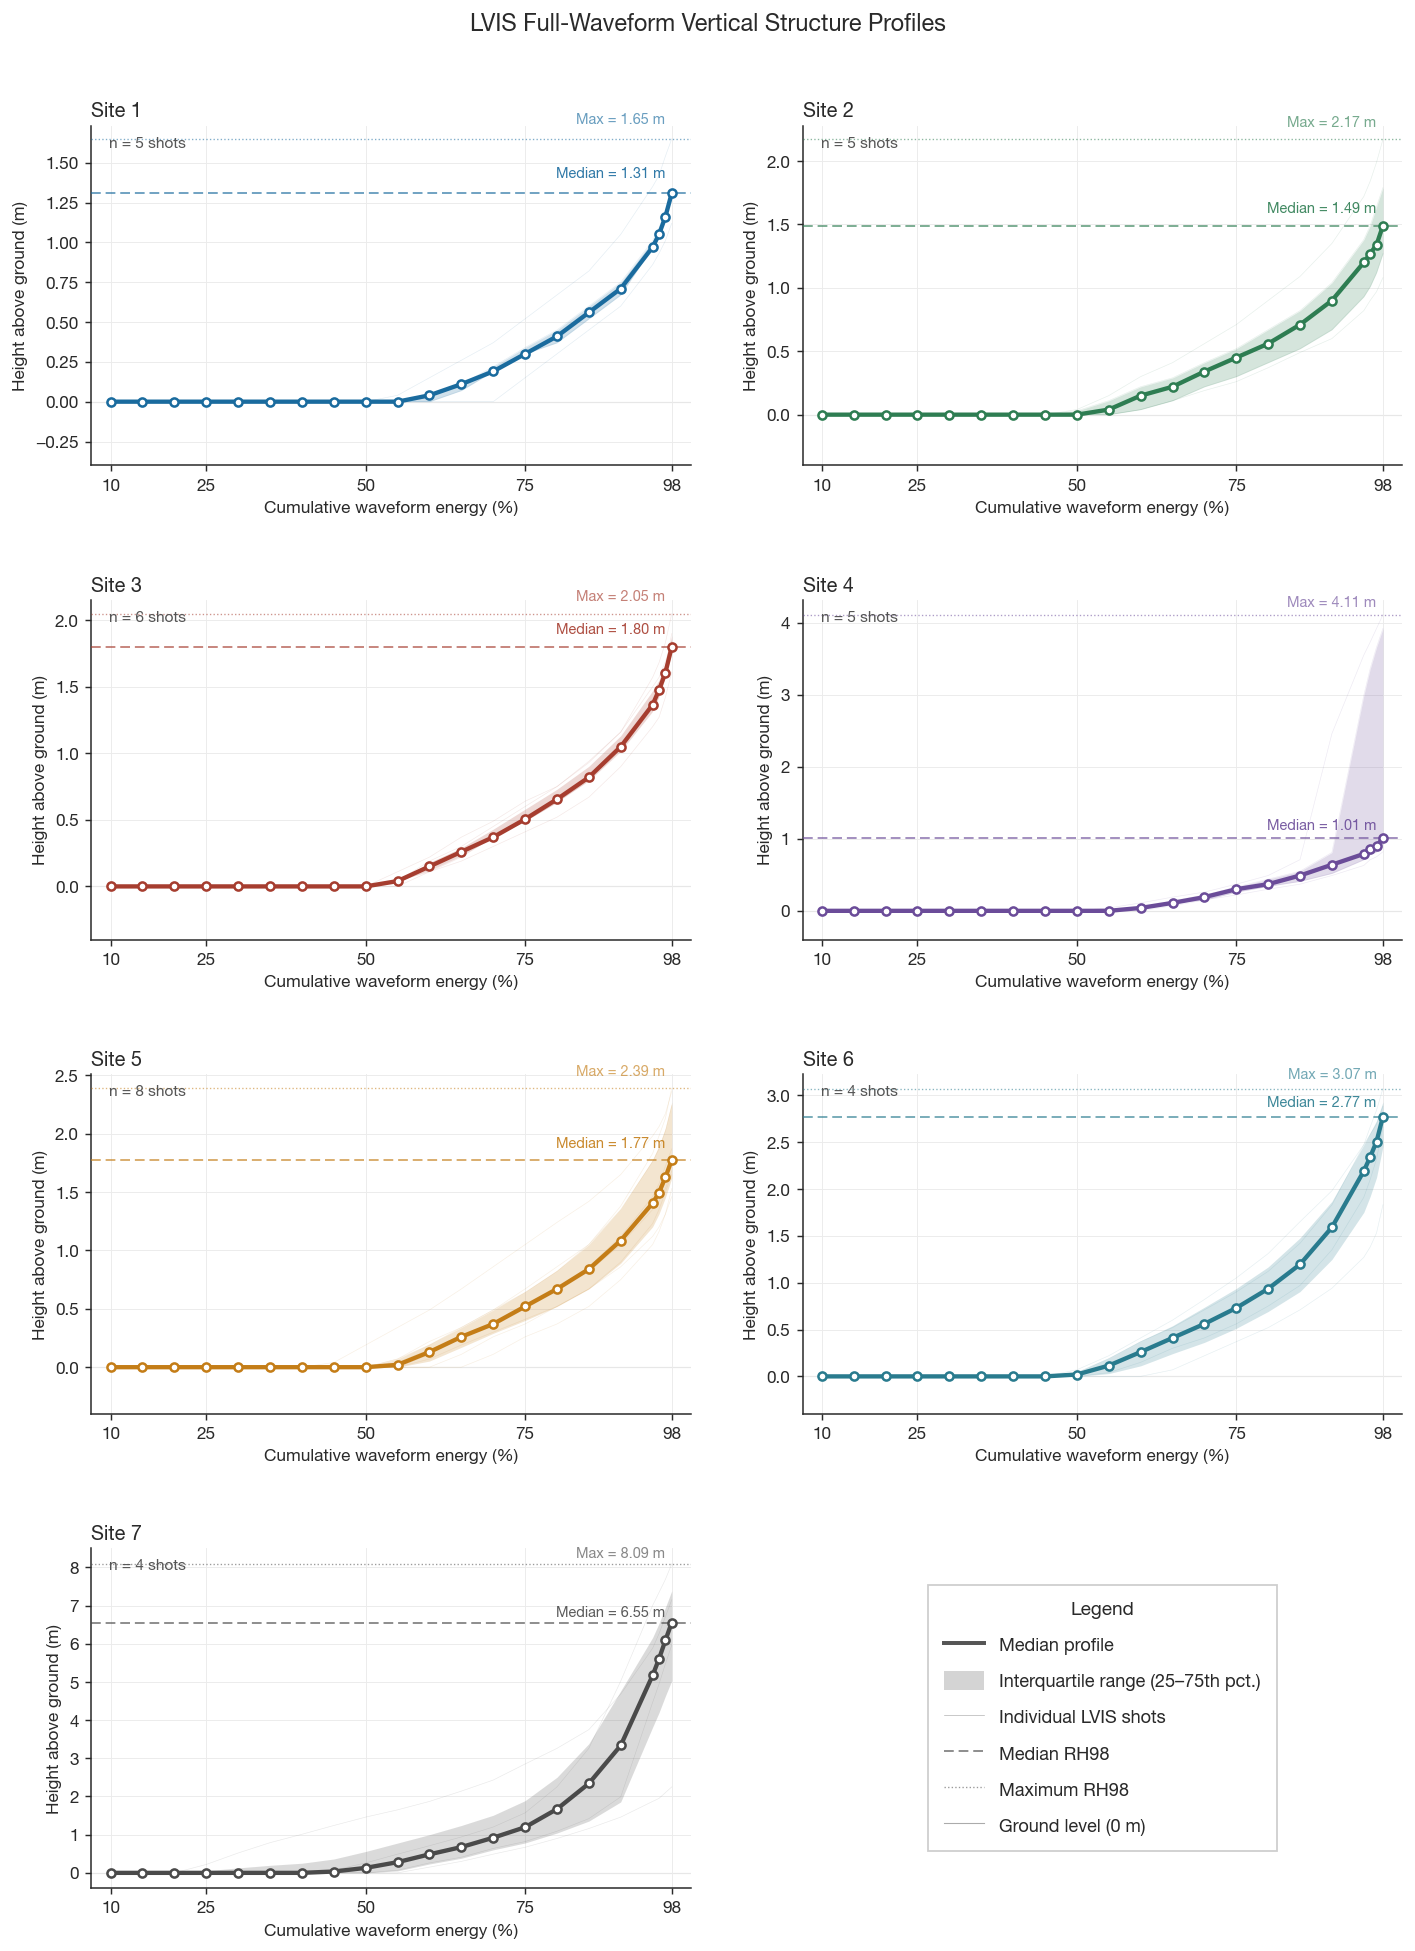

In [11]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(4, 2, figsize=(11, 15))
fig.suptitle(
    'LVIS Full-Waveform Vertical Structure Profiles',
    fontsize=13, y=0.998, linespacing=1.65
)
ax_flat = axes.flatten()
legend_handles = None

for idx, site in enumerate(SITE_ORDER):
    ax    = ax_flat[idx]
    color = SITE_COLORS[site]

    if site not in profile_stats:
        ax.text(0.5, 0.5, 'No shots\ninside plot',
                ha='center', va='center', transform=ax.transAxes,
                color='#999999', fontsize=10)
        ax.set_title(site, fontsize=11, fontweight='semibold', loc='left')
        continue

    s = profile_stats[site]
    x = PERCENTILES

    # Individual shot lines — very faint
    shots = s['all_shots']
    sample = shots[np.random.default_rng(99).choice(
        len(shots), size=min(50, len(shots)), replace=False)]
    for row in sample:
        ax.plot(x, row, color=color, linewidth=0.35, alpha=0.12, zorder=1)

    # IQR band
    ax.fill_between(x, s['q25'], s['q75'],
                    color=color, alpha=0.20, linewidth=0, zorder=2)

    # Median profile
    ax.plot(x, s['median'],
            color=color, linewidth=2.4, zorder=4, solid_capstyle='round',
            marker='o', markersize=4.5, markerfacecolor='white',
            markeredgecolor=color, markeredgewidth=1.4)

    # Median RH98 and Max RH98 reference lines
    med98 = s['median_rh98']
    max98 = s['max_rh98']
    ax.axhline(med98, color=color, linewidth=0.9,
               linestyle=(0, (6, 3)), alpha=0.75, zorder=3)
    ax.axhline(max98, color=color, linewidth=0.75,
               linestyle=':', alpha=0.55, zorder=3)
    ax.axhline(0, color='#888888', linewidth=0.6, alpha=0.5, zorder=0)

    # Labels for the reference lines
    x_label = max(x) - 1
    ax.text(x_label, med98 + 0.08, f'Median = {med98:.2f} m',
            fontsize=8, color=color, va='bottom', ha='right', alpha=0.9,
            fontweight='medium')
    ax.text(x_label, max98 + 0.08, f'Max = {max98:.2f} m',
            fontsize=8, color=color, va='bottom', ha='right', alpha=0.65)

    # Shot count
    ax.text(0.03, 0.97, f'n = {s["n"]} shots',
            transform=ax.transAxes, fontsize=8.5,
            va='top', ha='left', color='#555555')

    # Axes
    ax.set_title(site, fontsize=11, fontweight='semibold', loc='left', pad=5)
    ax.set_xlabel('Cumulative waveform energy (%)', fontsize=9.5)
    ax.set_ylabel('Height above ground (m)', fontsize=9.5)
    ax.set_xlim(min(x) - 3, max(x) + 3)
    ax.set_ylim(bottom=-0.4)
    ax.set_xticks([10, 25, 50, 75, 98])
    ax.set_xticklabels(['10', '25', '50', '75', '98'])

    if legend_handles is None:
        legend_handles = [
            Line2D([0],[0], color='#555555', linewidth=2.2,
                   label='Median profile'),
            Patch(facecolor='#555555', alpha=0.25, linewidth=0,
                  label='Interquartile range (25–75th pct.)'),
            Line2D([0],[0], color='#555555', linewidth=0.35, alpha=0.5,
                   label='Individual LVIS shots'),
            Line2D([0],[0], color='#555555', linewidth=0.9,
                   linestyle=(0,(6,3)), alpha=0.8, label='Median RH98'),
            Line2D([0],[0], color='#555555', linewidth=0.75,
                   linestyle=':', alpha=0.6, label='Maximum RH98'),
            Line2D([0],[0], color='#888888', linewidth=0.6, alpha=0.7,
                   label='Ground level (0 m)'),
        ]

# 8th panel = shared legend
legend_ax = ax_flat[-1]
legend_ax.axis('off')
if legend_handles:
    legend_ax.legend(handles=legend_handles, loc='center', fontsize=10,
                     title='Legend', title_fontsize=10.5,
                     frameon=True, edgecolor='#cccccc',
                     handlelength=2.2, handleheight=1.3,
                     labelspacing=0.9, borderpad=0.9)

fig.tight_layout(rect=[0, 0, 1, 0.985], h_pad=3.2, w_pad=2.8)

fig.savefig(os.path.join(OUTPUT_FOLDER, 'Figure_1_Waveform_Profiles.png'), dpi=300)
fig.savefig(os.path.join(OUTPUT_FOLDER, 'Figure_1_Waveform_Profiles.pdf'))
plt.show()

---
## Section 6 — Load Field Measurement Data

The spreadsheet contains the heights of the five tallest *L. argenteum* individuals
measured in each plot in September 2025.

> **Note on the LVIS column in the spreadsheet**  
> The column labelled *LVIS Relative Height* in your Excel file contains RH100 values
> extracted during an earlier analysis. We do not use it here — the LVIS values used
> in Figure 2 come directly from the `.TXT` files loaded in Section 4 (as RH98).


In [12]:
raw_excel = pd.read_excel(XLSX_PATH)

# Fill merged site-label cells downward
raw_excel['Site'] = raw_excel['Site'].ffill().str.strip()

# Keep only the field height column — ignore the old LVIS column
field_data = (raw_excel[['Site', 'Measured Silvertree Height (m)']]
              .rename(columns={'Measured Silvertree Height (m)': 'field_height_m'})
              .dropna()
              .copy())

print("Field-measured Silvertree heights per site (September 2025):\n")
for site in SITE_ORDER:
    vals = sorted(
        field_data[field_data['Site'] == site]['field_height_m'].values,
        reverse=True
    )
    if vals:
        print(f"  {site} ({len(vals)} trees):  "
              + '  '.join([f'{v:.2f} m' for v in vals]))

Field-measured Silvertree heights per site (September 2025):

  Site 1 (5 trees):  3.25 m  3.06 m  2.30 m  2.05 m  1.70 m
  Site 2 (5 trees):  4.30 m  3.90 m  3.35 m  2.90 m  2.60 m
  Site 3 (5 trees):  3.40 m  3.30 m  3.10 m  3.10 m  2.80 m
  Site 4 (5 trees):  1.90 m  1.60 m  1.50 m  1.20 m  1.10 m
  Site 5 (5 trees):  2.50 m  2.30 m  1.90 m  1.90 m  1.60 m
  Site 6 (5 trees):  6.70 m  6.50 m  6.50 m  6.20 m  4.80 m
  Site 7 (5 trees):  10.20 m  10.10 m  10.10 m  9.00 m  6.60 m


---
## Section 7 — Figure 2: LiDAR RH98 vs Field-Measured Heights

Two panels, same axes, same style:

**Panel (a) — All paired observations**  
Within each site the LVIS shots and field trees are sorted by height and paired
rank-to-rank (tallest LiDAR shot with tallest field tree, etc.). This gives the
maximum number of data points possible given the small number of shots per plot.

**Panel (b) — Per-plot maxima**  
One point per site: the highest RH98 shot in the plot vs the tallest field tree.
Seven points total. This is the most conservative and unambiguous comparison.

**On the temporal gap**  
LiDAR was acquired October–November 2023; field heights were measured September 2025
(~23 months later). *L. argenteum* grows ~0.8–1.0 m/year, so field trees are
expected to be 1.5–2.0 m taller than at acquisition. Points above the 1:1 line are
therefore ecologically expected, not a sensor error — this is stated in the caption.


In [13]:
# Build paired dataset (Panel a)
pair_rows = []
for site in SITE_ORDER:
    lvis_sorted  = np.sort(
        lvis_by_site[lvis_by_site['site'] == site]['RH98'].dropna().values)
    field_sorted = np.sort(
        field_data[field_data['Site'] == site]['field_height_m'].dropna().values)
    n = min(len(lvis_sorted), len(field_sorted))
    for i in range(n):
        pair_rows.append({
            'site'        : site,
            'lvis_rh98'   : lvis_sorted[i],
            'field_height': field_sorted[i],
        })
pairs_df = pd.DataFrame(pair_rows)

# Build per-plot maxima (Panel b)
maxima_rows = []
for site in SITE_ORDER:
    lvis_vals  = lvis_by_site[lvis_by_site['site'] == site]['RH98'].dropna()
    field_vals = field_data[field_data['Site'] == site]['field_height_m'].dropna()
    if lvis_vals.empty or field_vals.empty:
        continue
    maxima_rows.append({
        'site'        : site,
        'lvis_rh98'   : lvis_vals.max(),
        'field_height': field_vals.max(),
    })
maxima_df = pd.DataFrame(maxima_rows)

print(f"Panel (a) paired observations : {len(pairs_df)}")
print(f"Panel (b) per-plot maxima     : {len(maxima_df)}")

Panel (a) paired observations : 33
Panel (b) per-plot maxima     : 7


In [14]:
# Regression helper
def run_regression(x_arr, y_arr, confidence=0.95):
    """Fit OLS regression and return statistics + confidence band arrays."""
    n    = len(x_arr)
    lr   = linregress(x_arr, y_arr)
    yhat = lr.slope * x_arr + lr.intercept
    rmse = sqrt(np.mean((y_arr - yhat) ** 2))
    mae  = np.mean(np.abs(y_arr - yhat))
    r2   = lr.rvalue ** 2
    p_str = f'{lr.pvalue:.3f}' if lr.pvalue >= 0.001 else f'{lr.pvalue:.2e}'

    # Confidence band
    lo   = x_arr.min() - 0.3
    hi   = x_arr.max() + 0.3
    xx   = np.linspace(lo, hi, 300)
    yy   = lr.slope * xx + lr.intercept
    xm   = x_arr.mean()
    se   = lr.stderr * np.sqrt(1/n + (xx - xm)**2 / np.sum((x_arr - xm)**2))
    tcrit = t_dist.ppf((1 + confidence) / 2, df=n - 2)

    return dict(n=n, slope=lr.slope, intercept=lr.intercept,
                r2=r2, rmse=rmse, mae=mae, p_str=p_str,
                xx=xx, yy=yy,
                ci_low=yy - tcrit*se, ci_high=yy + tcrit*se)

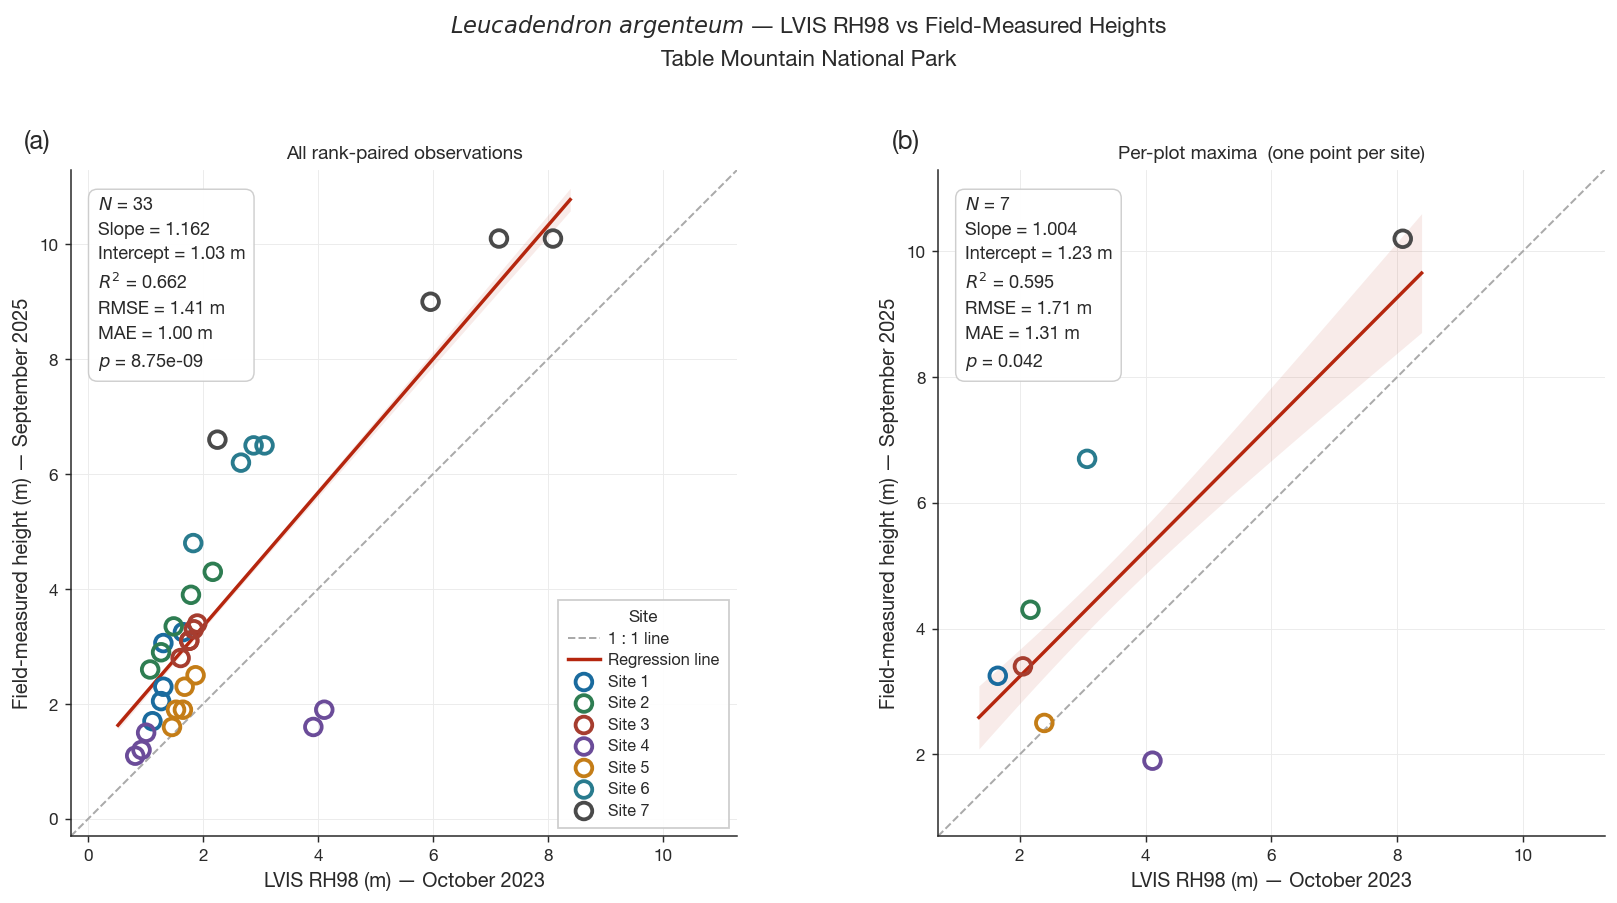

In [15]:
# Figure 2
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 6.5))

fig.suptitle(
    r'$\it{Leucadendron\ argenteum}$ — LVIS RH98 vs Field-Measured Heights'
    '\nTable Mountain National Park',
    fontsize=12.5, y=1.03, linespacing=1.65
)

datasets = [
    (ax_a, pairs_df,  '(a)', 'All rank-paired observations'),
    (ax_b, maxima_df, '(b)', 'Per-plot maxima  (one point per site)'),
]

for ax, df, panel_letter, subtitle in datasets:
    x = df['lvis_rh98'].values.astype(float)
    y = df['field_height'].values.astype(float)
    reg = run_regression(x, y)

    # Axis limits — square, equal aspect
    lo = np.floor(min(x.min(), y.min(), reg['ci_low'].min())) - 0.3
    hi = np.ceil( max(x.max(), y.max(), reg['ci_high'].max())) + 0.3

    # 1:1 reference line
    ax.plot([lo, hi], [lo, hi],
            color='#aaaaaa', linewidth=1.1, linestyle='--',
            zorder=1, label='1 : 1 line')

    # 95% confidence band
    ax.fill_between(reg['xx'], reg['ci_low'], reg['ci_high'],
                    color='#b5260e', alpha=0.09, linewidth=0, zorder=2)

    # Regression line
    ax.plot(reg['xx'], reg['yy'],
            color='#b5260e', linewidth=1.9, zorder=3,
            label='Regression line')

    # Data points — open rings coloured by site
    for site in SITE_ORDER:
        sub = df[df['site'] == site]
        if sub.empty:
            continue
        ax.scatter(sub['lvis_rh98'], sub['field_height'],
                   s=85, marker='o',
                   facecolors='none',
                   edgecolors=SITE_COLORS[site],
                   linewidths=2.1,
                   zorder=4,
                   label=site)

    # Stats annotation box
    stats_txt = (
        f'$N$ = {reg["n"]}\n'
        f'Slope = {reg["slope"]:.3f}\n'
        f'Intercept = {reg["intercept"]:.2f} m\n'
        f'$R^2$ = {reg["r2"]:.3f}\n'
        f'RMSE = {reg["rmse"]:.2f} m\n'
        f'MAE = {reg["mae"]:.2f} m\n'
        f'$p$ = {reg["p_str"]}'
    )
    ax.text(0.04, 0.96, stats_txt,
            transform=ax.transAxes, fontsize=10,
            va='top', ha='left', linespacing=1.6,
            bbox=dict(facecolor='white', edgecolor='#cccccc',
                      linewidth=0.8, alpha=0.96,
                      boxstyle='round,pad=0.5'))

    # Panel label
    ax.text(-0.07, 1.06, panel_letter,
            transform=ax.transAxes, fontsize=14,
            fontweight='bold', va='top', ha='left')

    # Axis formatting
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('LVIS RH98 (m) — October 2023', fontsize=11)
    ax.set_ylabel('Field-measured height (m) — September 2025', fontsize=11)
    ax.set_title(subtitle, fontsize=10.5, pad=6)

    # Legend on panel (a) only
    if ax is ax_a:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels,
                  title='Site', loc='lower right',
                  fontsize=9, title_fontsize=9.5,
                  frameon=True, edgecolor='#cccccc',
                  handletextpad=0.5, labelspacing=0.4)

fig.tight_layout(w_pad=4.5, rect=[0, 0, 1, 0.97])

fig.savefig(os.path.join(OUTPUT_FOLDER, 'Figure_2_LiDAR_vs_Field_Heights.png'), dpi=300)
fig.savefig(os.path.join(OUTPUT_FOLDER, 'Figure_2_LiDAR_vs_Field_Heights.pdf'))
plt.show()

---
## Section 8 — Summary Statistics

Run this to get the numbers ready to paste into your manuscript.

In [16]:
# Per-site canopy height summary
print("Per-site summary\n")
print(f"{'Site':8}  {'LVIS shots':>10}  {'LVIS med RH98':>14}  "
      f"{'LVIS max RH98':>14}  {'Field trees':>11}  {'Field max ht':>12}")
print('─' * 78)

for site in SITE_ORDER:
    lvis_sub  = lvis_by_site[lvis_by_site['site'] == site]['RH98'].dropna()
    field_sub = field_data[field_data['Site'] == site]['field_height_m'].dropna()
    if lvis_sub.empty or field_sub.empty:
        continue
    print(f"{site:8}  {len(lvis_sub):>10}  {lvis_sub.median():>13.2f} m  "
          f"{lvis_sub.max():>13.2f} m  {len(field_sub):>11}  "
          f"{field_sub.max():>11.2f} m")

# Regression summaries
print("\n")
for label, df in [("Panel (a) — All pairs", pairs_df),
                  ("Panel (b) — Plot maxima", maxima_df)]:
    x = df['lvis_rh98'].values.astype(float)
    y = df['field_height'].values.astype(float)
    reg = run_regression(x, y)
    print(f"{label}  (N = {reg['n']})")
    print(f"  R²        = {reg['r2']:.3f}")
    print(f"  RMSE      = {reg['rmse']:.2f} m")
    print(f"  MAE       = {reg['mae']:.2f} m")
    print(f"  Slope     = {reg['slope']:.3f}")
    print(f"  Intercept = {reg['intercept']:.2f} m")
    print(f"  p-value   = {reg['p_str']}")
    print()

Per-site summary

Site      LVIS shots   LVIS med RH98   LVIS max RH98  Field trees  Field max ht
──────────────────────────────────────────────────────────────────────────────
Site 1             5           1.31 m           1.65 m            5         3.25 m
Site 2             5           1.49 m           2.17 m            5         4.30 m
Site 3             6           1.80 m           2.05 m            5         3.40 m
Site 4             5           1.01 m           4.11 m            5         1.90 m
Site 5             8           1.77 m           2.39 m            5         2.50 m
Site 6             4           2.77 m           3.07 m            5         6.70 m
Site 7             4           6.55 m           8.09 m            5        10.20 m


Panel (a) — All pairs  (N = 33)
  R²        = 0.662
  RMSE      = 1.41 m
  MAE       = 1.00 m
  Slope     = 1.162
  Intercept = 1.03 m
  p-value   = 8.75e-09

Panel (b) — Plot maxima  (N = 7)
  R²        = 0.595
  RMSE      = 1.71 m
  MAE  

---
## Done ✓

Your two figures are in the `outputs/figures` folder:

- `Figure_1_Waveform_Profiles.png / .pdf`
- `Figure_2_LiDAR_vs_Field_Heights.png / .pdf`

Copy the numbers printed in Section 8 into your Results section.

---
*Rutlokoane & O'Farrell — BioSCape LiDAR analysis*
